In [2]:
import os
import json

# 1. Insert your Kaggle username and token here
kaggle_creds = {
    "username": "Burhan_086",
    "key": "KGAT_83d4d8fd9c2f420a8c697931417ca6b5"
}

# 2. Create the hidden .kaggle directory
os.makedirs('/root/.kaggle', exist_ok=True)

# 3. Write the credentials to the required kaggle.json file
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

# 4. Secure the file permissions (Kaggle requires this for security)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("Kaggle credentials configured successfully!")

Kaggle credentials configured successfully!


In [3]:
# Download the dataset directly from Kaggle
print("Downloading dataset...")
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Extract the dataset to our local dataset folder
print("Extracting dataset...")
!unzip -q chest-xray-pneumonia.zip -d /content/dataset/
print("Done! Data is ready for the PyTorch loaders.")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:31<00:00, 78.0MB/s]

Extracting dataset...
Done! Data is ready for the PyTorch loaders.


Using device: cuda
Training images: 5216
Validation images: 16
Testing images: 624


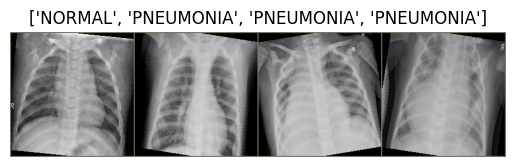

In [4]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Define Paths (These point to your newly unzipped local data)
# Note: Sometimes extracting Kaggle zips creates nested folders.
# We'll set the base path based on standard Kaggle structure.
base_dir = '/content/dataset/chest_xray'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# 3. Define Image Transformations
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4. Load Datasets
train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
val_data = datasets.ImageFolder(val_dir, transform=test_transforms)
test_data = datasets.ImageFolder(test_dir, transform=test_transforms)

# 5. Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Training images: {len(train_data)}")
print(f"Validation images: {len(val_data)}")
print(f"Testing images: {len(test_data)}")

# 6. Visualize a batch to confirm it worked
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.pause(0.001)

inputs, classes = next(iter(train_loader))
out = torchvision.utils.make_grid(inputs[:4])
class_names = train_data.classes
imshow(out, title=[class_names[x] for x in classes[:4]])

In [5]:
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()

        # Block 1: Input image is 3 channels (RGB). We output 32 feature maps.
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2: 32 channels in, 64 out.
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 3: 64 channels in, 128 out.
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layers
        # Math: Input was 224x224. Pooled 3 times (divided by 2 each time) -> 28x28.
        # Flattened size: 128 channels * 28 * 28 = 100,352 parameters.
        self.fc1 = nn.Linear(128 * 28 * 28, 512)

        # Dropout randomly turns off 50% of neurons during training to prevent overfitting
        self.dropout = nn.Dropout(0.5)

        # Final output layer: 2 neurons (Normal vs. Pneumonia)
        self.fc2 = nn.Linear(512, 2)

    def forward(self, x):
        # Pass data through convolutions, apply ReLU activation, then pool
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))

        # Flatten the 3D tensor into a 1D vector for the linear layers
        x = x.view(-1, 128 * 28 * 28)

        # Pass through dense layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Instantiate the model and move it to the GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_cnn = CustomCNN().to(device)

print(model_cnn)

CustomCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=2, bias=True)
)


In [6]:
import torch.optim as optim

# CrossEntropyLoss is standard for multi-class/binary classification in PyTorch
criterion = nn.CrossEntropyLoss()

# Adam optimizer is highly efficient. We set a small learning rate (0.001)
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001)

print("Loss function and optimizer defined. Ready to train!")

Loss function and optimizer defined. Ready to train!


In [7]:
import time

# Number of times we will pass the entire dataset through the network
num_epochs = 10

# Lists to track performance for plotting later
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

print("Starting Training Loop on the GPU...")
start_time = time.time()

for epoch in range(num_epochs):
    # ========================
    # 1. TRAINING PHASE
    # ========================
    model_cnn.train() # Set model to training mode (enables Dropout)
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Zero the parameter gradients so they don't accumulate
        optimizer.zero_grad()

        # Forward pass: compute predicted outputs
        outputs = model_cnn(inputs)
        loss = criterion(outputs, labels)

        # Get the actual class predictions
        _, preds = torch.max(outputs, 1)

        # Backward pass: compute gradient of the loss
        loss.backward()

        # Optimizer step: update the weights
        optimizer.step()

        # Update statistics
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.double() / total_train

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc.item())

    # ========================
    # 2. VALIDATION PHASE
    # ========================
    model_cnn.eval() # Set model to evaluation mode (disables Dropout for fair testing)
    val_loss = 0.0
    val_corrects = 0
    total_val = 0

    # Disable gradient calculation for validation (saves massive memory and compute)
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model_cnn(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)
            total_val += inputs.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = val_corrects.double() / total_val

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc.item())

    # Print epoch summary
    print(f'Epoch [{epoch+1}/{num_epochs}] | '
          f'Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.4f} | '
          f'Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.4f}')

end_time = time.time()
print(f"\nTraining complete in {(end_time - start_time)//60:.0f}m {(end_time - start_time)%60:.0f}s")

Starting Training Loop on the GPU...
Epoch [1/10] | Train Loss: 0.3697 - Train Acc: 0.8656 | Val Loss: 1.4160 - Val Acc: 0.5625
Epoch [2/10] | Train Loss: 0.1640 - Train Acc: 0.9419 | Val Loss: 1.1151 - Val Acc: 0.6250
Epoch [3/10] | Train Loss: 0.1360 - Train Acc: 0.9488 | Val Loss: 0.6024 - Val Acc: 0.6875
Epoch [4/10] | Train Loss: 0.1149 - Train Acc: 0.9594 | Val Loss: 0.6134 - Val Acc: 0.6250
Epoch [5/10] | Train Loss: 0.0942 - Train Acc: 0.9657 | Val Loss: 0.8916 - Val Acc: 0.6875
Epoch [6/10] | Train Loss: 0.1028 - Train Acc: 0.9636 | Val Loss: 1.0678 - Val Acc: 0.6250
Epoch [7/10] | Train Loss: 0.0938 - Train Acc: 0.9649 | Val Loss: 0.7944 - Val Acc: 0.6250
Epoch [8/10] | Train Loss: 0.0871 - Train Acc: 0.9670 | Val Loss: 0.9282 - Val Acc: 0.6250
Epoch [9/10] | Train Loss: 0.0795 - Train Acc: 0.9714 | Val Loss: 0.3590 - Val Acc: 0.8125
Epoch [10/10] | Train Loss: 0.0737 - Train Acc: 0.9703 | Val Loss: 0.4023 - Val Acc: 0.7500

Training complete in 14m 41s


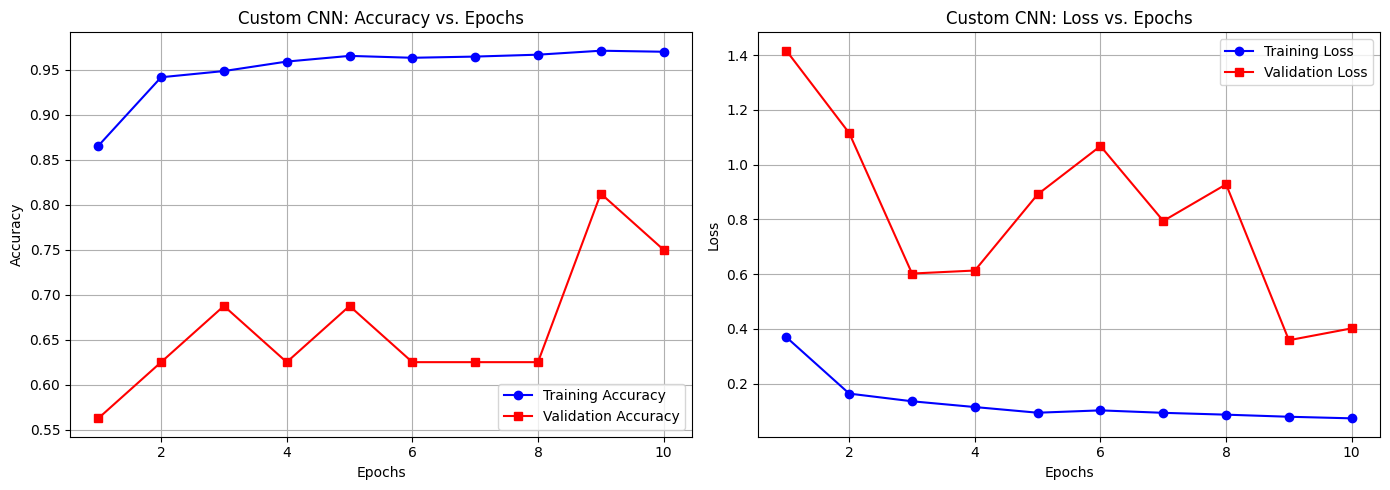

Baseline model weights saved successfully!


In [8]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracies, 'b-o', label='Training Accuracy')
plt.plot(epochs, val_accuracies, 'r-s', label='Validation Accuracy')
plt.title('Custom CNN: Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, 'b-o', label='Training Loss')
plt.plot(epochs, val_losses, 'r-s', label='Validation Loss')
plt.title('Custom CNN: Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Let's also save the baseline model weights so we don't lose them!
torch.save(model_cnn.state_dict(), 'custom_cnn_baseline.pth')
print("Baseline model weights saved successfully!")

In [9]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

# 1. Load the pre-trained ResNet50 model
# (Note: 'weights=models.ResNet50_Weights.DEFAULT' is the modern PyTorch way to load pre-trained weights)
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 2. Freeze all the base layers (the "body")
# This tells PyTorch NOT to update these weights during backpropagation.
for param in resnet.parameters():
    param.requires_grad = False

# 3. Replace the final classification layer (the "head")
# ResNet50's final layer is called 'fc' (fully connected). We find out how many inputs it takes...
num_ftrs = resnet.fc.in_features

# ...and replace it with a new sequential block for our 2 classes.
# We include Dropout here to further prevent overfitting.
resnet.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, 2)
)

# Move the model to the GPU
resnet = resnet.to(device)

# 4. Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()

# CRITICAL: We only pass the parameters of our NEW 'fc' layer to the optimizer.
# We are only training the head, not the whole body!
optimizer_resnet = optim.Adam(resnet.fc.parameters(), lr=0.001)

print("Pre-trained ResNet50 loaded, frozen, and modified for 2-class diagnosis!")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 181MB/s]


Pre-trained ResNet50 loaded, frozen, and modified for 2-class diagnosis!


In [10]:
import time

num_epochs = 10
resnet_train_losses, resnet_val_losses = [], []
resnet_train_acc, resnet_val_acc = [], []

print("Starting Transfer Learning Training on ResNet50...")
start_time = time.time()

for epoch in range(num_epochs):
    # --- TRAINING ---
    resnet.train()
    running_loss, running_corrects, total_train = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_resnet.zero_grad()
        outputs = resnet(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.double() / total_train
    resnet_train_losses.append(epoch_train_loss)
    resnet_train_acc.append(epoch_train_acc.item())

    # --- VALIDATION ---
    resnet.eval()
    val_loss, val_corrects, total_val = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)
            total_val += inputs.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = val_corrects.double() / total_val
    resnet_val_losses.append(epoch_val_loss)
    resnet_val_acc.append(epoch_val_acc.item())

    print(f'Epoch [{epoch+1}/{num_epochs}] | '
          f'Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.4f} | '
          f'Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.4f}')

end_time = time.time()
print(f"\nResNet50 Training complete in {(end_time - start_time)//60:.0f}m {(end_time - start_time)%60:.0f}s")

# Save the weights!
torch.save(resnet.state_dict(), 'resnet50_pneumonia.pth')

Starting Transfer Learning Training on ResNet50...
Epoch [1/10] | Train Loss: 0.2985 - Train Acc: 0.8725 | Val Loss: 0.5610 - Val Acc: 0.6250
Epoch [2/10] | Train Loss: 0.2133 - Train Acc: 0.9145 | Val Loss: 0.6972 - Val Acc: 0.6250
Epoch [3/10] | Train Loss: 0.1972 - Train Acc: 0.9208 | Val Loss: 0.8060 - Val Acc: 0.6250
Epoch [4/10] | Train Loss: 0.1793 - Train Acc: 0.9268 | Val Loss: 0.5409 - Val Acc: 0.7500
Epoch [5/10] | Train Loss: 0.1745 - Train Acc: 0.9323 | Val Loss: 0.7841 - Val Acc: 0.6250
Epoch [6/10] | Train Loss: 0.1665 - Train Acc: 0.9377 | Val Loss: 0.7585 - Val Acc: 0.6250
Epoch [7/10] | Train Loss: 0.1646 - Train Acc: 0.9340 | Val Loss: 0.9323 - Val Acc: 0.6250
Epoch [8/10] | Train Loss: 0.1681 - Train Acc: 0.9348 | Val Loss: 0.5110 - Val Acc: 0.7500
Epoch [9/10] | Train Loss: 0.1550 - Train Acc: 0.9377 | Val Loss: 0.7787 - Val Acc: 0.6250
Epoch [10/10] | Train Loss: 0.1663 - Train Acc: 0.9323 | Val Loss: 0.6445 - Val Acc: 0.6875

ResNet50 Training complete in 14m 27s

In [11]:
print("Evaluating ResNet50 on the Test Set (624 images)...")

resnet.eval() # Ensure model is in eval mode
test_loss = 0.0
test_corrects = 0
total_test = 0

# We don't need gradients for testing
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = resnet(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        test_loss += loss.item() * inputs.size(0)
        test_corrects += torch.sum(preds == labels.data)
        total_test += inputs.size(0)

final_test_loss = test_loss / total_test
final_test_acc = test_corrects.double() / total_test

print(f'Test Loss: {final_test_loss:.4f}')
print(f'True Test Accuracy: {final_test_acc * 100:.2f}%')

Evaluating ResNet50 on the Test Set (624 images)...
Test Loss: 0.4374
True Test Accuracy: 83.65%


In [12]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

print("Loading pre-trained Vision Transformer (ViT-Base-16)...")

# 1. Load the pre-trained ViT
# We use the Base model with patch size 16 (a standard, highly effective configuration)
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

# 2. Freeze the complex attention blocks (the "body")
for param in vit.parameters():
    param.requires_grad = False

# 3. Replace the final classification head
# In torchvision's ViT, the final layer is accessed via 'heads.head'
num_ftrs_vit = vit.heads.head.in_features

# We replace it with a simple linear layer for our 2 classes (Normal vs Pneumonia)
vit.heads.head = nn.Linear(num_ftrs_vit, 2)

# Move the massive model to the GPU
vit = vit.to(device)

# 4. Define Optimizer for the new head
criterion = nn.CrossEntropyLoss()
optimizer_vit = optim.Adam(vit.heads.head.parameters(), lr=0.001)

print("ViT loaded, frozen, and modified! Ready for training.")

Loading pre-trained Vision Transformer (ViT-Base-16)...
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:03<00:00, 102MB/s]


ViT loaded, frozen, and modified! Ready for training.


In [13]:
import time

num_epochs = 10
vit_train_losses, vit_val_losses = [], []
vit_train_acc, vit_val_acc = [], []

print("Starting Transfer Learning Training on Vision Transformer...")
start_time = time.time()

for epoch in range(num_epochs):
    # --- TRAINING ---
    vit.train()
    running_loss, running_corrects, total_train = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_vit.zero_grad()
        outputs = vit(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        loss.backward()
        optimizer_vit.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.double() / total_train
    vit_train_losses.append(epoch_train_loss)
    vit_train_acc.append(epoch_train_acc.item())

    # --- VALIDATION (Ignore the roller coaster here, we know the val set is tiny) ---
    vit.eval()
    val_loss, val_corrects, total_val = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vit(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)
            total_val += inputs.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = val_corrects.double() / total_val
    vit_val_losses.append(epoch_val_loss)
    vit_val_acc.append(epoch_val_acc.item())

    print(f'Epoch [{epoch+1}/{num_epochs}] | '
          f'Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.4f} | '
          f'Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.4f}')

end_time = time.time()
print(f"\nViT Training complete in {(end_time - start_time)//60:.0f}m {(end_time - start_time)%60:.0f}s")

# Save the ViT weights
torch.save(vit.state_dict(), 'vit_pneumonia.pth')
print("ViT weights saved!")

Starting Transfer Learning Training on Vision Transformer...
Epoch [1/10] | Train Loss: 0.1760 - Train Acc: 0.9302 | Val Loss: 0.4580 - Val Acc: 0.7500
Epoch [2/10] | Train Loss: 0.1095 - Train Acc: 0.9599 | Val Loss: 0.4688 - Val Acc: 0.8125
Epoch [3/10] | Train Loss: 0.0944 - Train Acc: 0.9655 | Val Loss: 0.3926 - Val Acc: 0.8125
Epoch [4/10] | Train Loss: 0.0822 - Train Acc: 0.9701 | Val Loss: 0.3176 - Val Acc: 0.8750
Epoch [5/10] | Train Loss: 0.0757 - Train Acc: 0.9734 | Val Loss: 0.2917 - Val Acc: 0.9375
Epoch [6/10] | Train Loss: 0.0795 - Train Acc: 0.9695 | Val Loss: 0.4541 - Val Acc: 0.8125
Epoch [7/10] | Train Loss: 0.0737 - Train Acc: 0.9722 | Val Loss: 0.4693 - Val Acc: 0.8125
Epoch [8/10] | Train Loss: 0.0727 - Train Acc: 0.9737 | Val Loss: 0.4146 - Val Acc: 0.8750
Epoch [9/10] | Train Loss: 0.0703 - Train Acc: 0.9745 | Val Loss: 0.4477 - Val Acc: 0.8750
Epoch [10/10] | Train Loss: 0.0674 - Train Acc: 0.9781 | Val Loss: 0.3571 - Val Acc: 0.8750

ViT Training complete in 17

In [14]:
print("Evaluating Vision Transformer (ViT) on the Test Set (624 images)...")

vit.eval() # Ensure the transformer is in evaluation mode
test_loss = 0.0
test_corrects = 0
total_test = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = vit(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        test_loss += loss.item() * inputs.size(0)
        test_corrects += torch.sum(preds == labels.data)
        total_test += inputs.size(0)

final_test_loss = test_loss / total_test
final_test_acc = test_corrects.double() / total_test

print(f'Test Loss: {final_test_loss:.4f}')
print(f'True Test Accuracy: {final_test_acc * 100:.2f}%')

Evaluating Vision Transformer (ViT) on the Test Set (624 images)...
Test Loss: 0.4004
True Test Accuracy: 86.06%


In [15]:
import torch.nn.functional as F
from PIL import Image

def predict_ensemble(image_path, model_1, model_2, device, class_names=['Normal', 'Pneumonia']):
    """
    Takes an image path, runs it through two models, averages their
    softmax probabilities, and returns the final diagnosis.
    """
    # 1. Open and preprocess the image
    image = Image.open(image_path).convert('RGB')

    # We use the test_transforms we defined in Phase 1
    input_tensor = test_transforms(image).unsqueeze(0).to(device)

    # 2. Set both models to evaluation mode
    model_1.eval()
    model_2.eval()

    with torch.no_grad():
        # 3. Get raw outputs (logits)
        output_1 = model_1(input_tensor)
        output_2 = model_2(input_tensor)

        # 4. Convert to probabilities using Softmax
        prob_1 = F.softmax(output_1, dim=1)
        prob_2 = F.softmax(output_2, dim=1)

        # 5. Average the probabilities
        ensemble_prob = (prob_1 + prob_2) / 2.0

        # 6. Get the final predicted class and its confidence score
        confidence, predicted_class = torch.max(ensemble_prob, 1)

    result = class_names[predicted_class.item()]
    conf_score = confidence.item() * 100

    print(f"ResNet Probability: {prob_1[0].cpu().numpy()}")
    print(f"ViT Probability:    {prob_2[0].cpu().numpy()}")
    print(f"---")
    print(f"Final Ensemble Diagnosis: {result} (Confidence: {conf_score:.2f}%)")

    return result, conf_score

print("Ensemble inference function ready!")

Ensemble inference function ready!


In [16]:
import glob
import random

# Find all Pneumonia test images
pneumonia_test_images = glob.glob('/content/dataset/chest_xray/test/PNEUMONIA/*.jpeg')

# Pick a random one
test_image_path = random.choice(pneumonia_test_images)

print(f"Testing image: {test_image_path}\n")

# Run the ensemble! (Passing our trained ResNet and ViT)
predict_ensemble(test_image_path, resnet, vit, device)

Testing image: /content/dataset/chest_xray/test/PNEUMONIA/person10_virus_35.jpeg

ResNet Probability: [0.00805617 0.99194384]
ViT Probability:    [0.0014097 0.9985903]
---
Final Ensemble Diagnosis: Pneumonia (Confidence: 99.53%)


('Pneumonia', 99.52670335769653)


Generating Grad-CAM Heatmap...


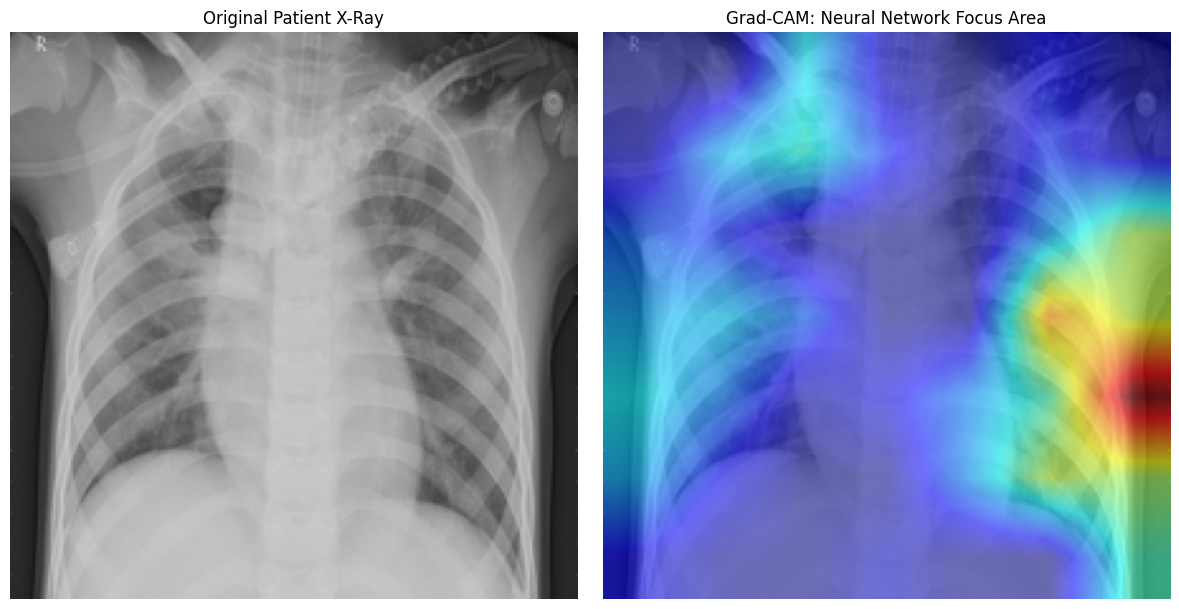

In [18]:
# 1. Install the industry-standard Grad-CAM library (if not already done)
# !pip install -q grad-cam

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image

print("\nGenerating Grad-CAM Heatmap...")

# 2. Prepare the original image for visualization
img = Image.open(test_image_path).convert('RGB')
img_resized = img.resize((224, 224))
rgb_img = np.float32(img_resized) / 255

# 3. Prepare the tensor for the model
input_tensor = test_transforms(img).unsqueeze(0).to(device)

# ==========================================
# THE FIX: UNFREEZE THE MODEL FOR GRAD-CAM
# ==========================================
for param in resnet.parameters():
    param.requires_grad = True

# 4. Configure Grad-CAM
target_layers = [resnet.layer4[-1]]
cam = GradCAM(model=resnet, target_layers=target_layers)

# We want to see why it predicted Class 1 (Pneumonia)
targets = [ClassifierOutputTarget(1)]

# 5. Generate the heatmap
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
grayscale_cam = grayscale_cam[0, :] # Extract the 2D map

# 6. Overlay the heatmap
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# 7. Plot the results side-by-side
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_resized)
plt.title("Original Patient X-Ray")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title("Grad-CAM: Neural Network Focus Area")
plt.axis('off')

plt.tight_layout()
plt.show()

In [24]:
%%writefile app.py
import streamlit as st
import torch
import torchvision.models as models
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import torch.nn.functional as F
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# --- UI Setup ---
st.set_page_config(page_title="Medical Image Diagnosis", layout="wide")
st.title("Multi-Model Medical Image Diagnosis System")
st.write("Upload a Chest X-Ray to receive an ensemble diagnosis (ResNet50 + ViT) and Grad-CAM analysis.")

# --- Load Models (Cached so they don't reload on every click) ---
@st.cache_resource
def load_models():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load ResNet
    resnet = models.resnet50()
    num_ftrs = resnet.fc.in_features
    resnet.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_ftrs, 2))
    resnet.load_state_dict(torch.load('resnet50_pneumonia.pth', map_location=device))
    resnet = resnet.to(device)
    resnet.eval()
    for param in resnet.parameters():
        param.requires_grad = True # Required for Grad-CAM

    # Load ViT
    vit = models.vit_b_16()
    num_ftrs_vit = vit.heads.head.in_features
    vit.heads.head = nn.Linear(num_ftrs_vit, 2)
    vit.load_state_dict(torch.load('vit_pneumonia.pth', map_location=device))
    vit = vit.to(device)
    vit.eval()

    return resnet, vit, device

resnet, vit, device = load_models()

# --- Image Processing ---
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

uploaded_file = st.file_uploader("Choose an X-ray image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Display the uploaded image
    image = Image.open(uploaded_file).convert('RGB')

    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Original X-Ray")
        # FIXED: Updated parameter to remove the deprecation warning
        st.image(image, use_container_width=True)

    # Run Inference
    with st.spinner("Analyzing with Ensemble Model..."):
        input_tensor = test_transforms(image).unsqueeze(0).to(device)

        with torch.no_grad():
            prob_resnet = F.softmax(resnet(input_tensor), dim=1)
            prob_vit = F.softmax(vit(input_tensor), dim=1)
            ensemble_prob = (prob_resnet + prob_vit) / 2.0
            confidence, predicted_class = torch.max(ensemble_prob, 1)

        classes = ['Normal', 'Pneumonia']
        result = classes[predicted_class.item()]
        conf_score = confidence.item() * 100

    st.success(f"**Diagnosis:** {result} (Confidence: {conf_score:.2f}%)")

    # Generate Grad-CAM
    with st.spinner("Generating Explainability Heatmap..."):
        target_layers = [resnet.layer4[-1]]
        cam = GradCAM(model=resnet, target_layers=target_layers)
        targets = [ClassifierOutputTarget(predicted_class.item())]

        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

        img_resized = image.resize((224, 224))
        rgb_img = np.float32(img_resized) / 255
        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    with col2:
        st.subheader("Grad-CAM Focus Area")
        # FIXED: Updated parameter to remove the deprecation warning
        st.image(visualization, use_container_width=True)

Overwriting app.py


In [26]:
# 1. Clear out any broken background processes
!pkill -f "streamlit"
!pkill -f "cloudflared"

# 2. Launch Streamlit in the background (with security shields down)
!streamlit run app.py --server.enableCORS=false --server.enableXsrfProtection=false &>/dev/null &

# 3. Give Streamlit 3 seconds to boot up fully
import time
time.sleep(3)

# 4. Run Cloudflare Tunnel in the FOREGROUND (This keeps the connection alive!)
print("Spinning up the secure tunnel...")
print("Look for the URL ending in '.trycloudflare.com' in the text below 👇")
print("======================================================================")

!./cloudflared-linux-amd64 tunnel --url http://localhost:8501

Spinning up the secure tunnel...
Look for the URL ending in '.trycloudflare.com' in the text below 👇
2026-04-20T19:32:00Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-04-20T19:32:00Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-04-20T19:32:03Z INF +--------------------------------------------------------------------------------------------+
2026-04-20T19:32:03Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time t